In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving hr_cleaned.csv to hr_cleaned.csv


In [ ]:
df=pd.read_csv("hr_cleaned.csv")

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age_Group,Income_Band,Tenure_Bucket,Attrition_Flag,OverTime_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,6,4,0,5,36-45,High,6-10 Years,1,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,10,7,1,7,46-55,High,6-10 Years,0,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,0,0,0,0,36-45,Low,0-2 Years,1,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,8,7,3,0,26-35,Low,6-10 Years,0,1
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,2,2,2,2,26-35,Medium,0-2 Years,0,0


In [ ]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'Age_Group',
 'Income_Band',
 'Tenure_Bucket',
 'Attrition_Flag',
 'OverTime_Flag']

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
X=df.drop(
    columns=[
        "Attrition",
        "EmployeeNumber",
        "Attrition_Flag",
        "OverTime_Flag"
    ]
)
y=df["Attrition"]

In [ ]:
print(X.shape)
print(y.shape)

(1470, 33)
(1470,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)

In [ ]:
print(y[:10])

[1 0 1 0 0 0 0 0 0 0]


In [ ]:
categorical_columns=X.select_dtypes(include=["object"]).columns
categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime', 'Age_Group', 'Income_Band',
       'Tenure_Bucket'],
      dtype='object')

In [ ]:
X=pd.get_dummies(X,drop_first=True)

In [ ]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Age_Group_26-35,Age_Group_36-45,Age_Group_46-55,Age_Group_56+,Income_Band_High,Income_Band_Low,Income_Band_Medium,Tenure_Bucket_10+ Years,Tenure_Bucket_3-5 Years,Tenure_Bucket_6-10 Years
0,41,1102,1,2,2,94,3,2,4,5993,...,False,True,False,False,True,False,False,False,False,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,True,False,False,False,False,True
2,37,1373,2,2,4,92,2,1,3,2090,...,False,True,False,False,False,True,False,False,False,False
3,33,1392,3,4,4,56,3,1,3,2909,...,True,False,False,False,False,True,False,False,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   Education                          1470 non-null   int64
 4   EnvironmentSatisfaction            1470 non-null   int64
 5   HourlyRate                         1470 non-null   int64
 6   JobInvolvement                     1470 non-null   int64
 7   JobLevel                           1470 non-null   int64
 8   JobSatisfaction                    1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  MonthlyRate                        1470 non-null   int64
 11  NumCompaniesWorked                 1470 non-null   int64
 12  PercentSalaryHike   

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print("Training Data Size : ",X_train.shape)
print("Testing Data Size : ",X_test.shape)

Training Data Size :  (1176, 54)
Testing Data Size :  (294, 54)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
tree_model=DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
print("All models trained successfully")

All models trained successfully


In [ ]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
log_pred=log_model.predict(X_test)
tree_pred=tree_model.predict(X_test)
rf_pred=rf_model.predict(X_test)

In [ ]:
models={
    "Logistic Regression":log_pred,
    "Decision Tree":tree_pred,
    "Random Forest":rf_pred
}
for name,prediction in models.items():
  print(f"\n{name}:")
  print(f"Accuracy: {accuracy_score(y_test,prediction)}")
  print(f"Precision: {precision_score(y_test,prediction)}")
  print(f"Recall: {recall_score(y_test,prediction)}")
  print(f"F1 Score: {f1_score(y_test,prediction)}")
  print(f"ROC AUC Score: {roc_auc_score(y_test,prediction)}")
  print(f"Confusion Matrix: \n{confusion_matrix(y_test,prediction)}")


Logistic Regression:
Accuracy: 0.8639455782312925
Precision: 0.8181818181818182
Recall: 0.19148936170212766
F1 Score: 0.3103448275862069
ROC AUC Score: 0.5916960978551123
Confusion Matrix: 
[[245   2]
 [ 38   9]]

Decision Tree:
Accuracy: 0.7789115646258503
Precision: 0.32
Recall: 0.3404255319148936
F1 Score: 0.32989690721649484
ROC AUC Score: 0.6013868550262728
Confusion Matrix: 
[[213  34]
 [ 31  16]]

Random Forest:
Accuracy: 0.8401360544217688
Precision: 0.5
Recall: 0.10638297872340426
F1 Score: 0.17543859649122806
ROC AUC Score: 0.5430700318718237
Confusion Matrix: 
[[242   5]
 [ 42   5]]


In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294



In [ ]:
print(confusion_matrix(y_test,rf_pred))

[[242   5]
 [ 42   5]]


In [ ]:
print(X_train.shape)
print(X_test.shape)

(1176, 54)
(294, 54)


In [ ]:
print(X.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_

In [ ]:
for i in X.columns.tolist():
  print(i)

Age
DailyRate
DistanceFromHome
Education
EnvironmentSatisfaction
HourlyRate
JobInvolvement
JobLevel
JobSatisfaction
MonthlyIncome
MonthlyRate
NumCompaniesWorked
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager
BusinessTravel_Travel_Frequently
BusinessTravel_Travel_Rarely
Department_Research & Development
Department_Sales
EducationField_Life Sciences
EducationField_Marketing
EducationField_Medical
EducationField_Other
EducationField_Technical Degree
Gender_Male
JobRole_Human Resources
JobRole_Laboratory Technician
JobRole_Manager
JobRole_Manufacturing Director
JobRole_Research Director
JobRole_Research Scientist
JobRole_Sales Executive
JobRole_Sales Representative
MaritalStatus_Married
MaritalStatus_Single
OverTime_Yes
Age_Group_26-35
Age_Group_36-45
Age_Group_46-55
Age_Group_56+
Income_Band_High
Income_Band_Low
Income_Band_M

In [ ]:
balanced_log_model=LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42)
balanced_log_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
balanced_pred=balanced_log_model.predict(X_test)

In [ ]:
print(f"\nBalanced Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test,balanced_pred)}")
print(f"Precision: {precision_score(y_test,balanced_pred)}")
print(f"Recall: {recall_score(y_test,balanced_pred)}")
print(f"F1 Score: {f1_score(y_test,balanced_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test,balanced_pred)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test,balanced_pred)}")


Balanced Logistic Regression:
Accuracy: 0.7312925170068028
Precision: 0.32608695652173914
Recall: 0.6382978723404256
F1 Score: 0.4316546762589928
ROC AUC Score: 0.6936428632957189
Confusion Matrix: 
[[185  62]
 [ 17  30]]


In [ ]:
prediction_probability=balanced_log_model.predict_proba(X_test)
prediction_probability[:5]

array([[0.50604947, 0.49395053],
       [0.7921785 , 0.2078215 ],
       [0.52624647, 0.47375353],
       [0.91528031, 0.08471969],
       [0.55944001, 0.44055999]])

In [ ]:
attrition_probability=prediction_probability[:1]
attrition_probability[:10]

array([[0.50604947, 0.49395053]])

In [ ]:
feature_importance=pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : abs(balanced_log_model.coef_[0])})

In [ ]:
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
43,OverTime_Yes,0.555105
15,StockOptionLevel,0.401661
42,MaritalStatus_Single,0.332970
4,EnvironmentSatisfaction,0.322937
49,Income_Band_Low,0.260604
26,Department_Sales,0.256425
8,JobSatisfaction,0.255908
23,BusinessTravel_Travel_Frequently,0.243121
45,Age_Group_36-45,0.233200
34,JobRole_Laboratory Technician,0.214178


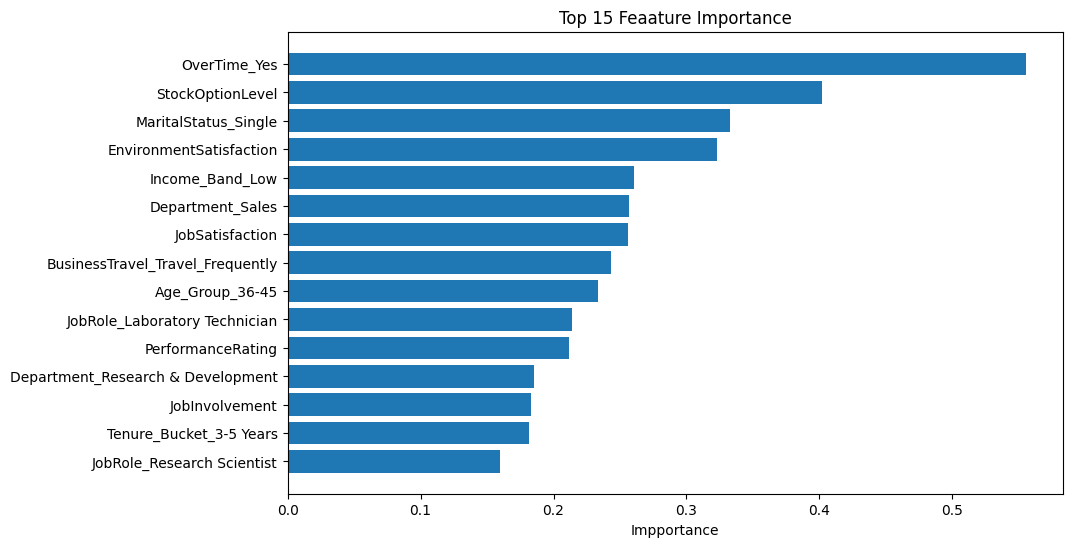

In [ ]:
import matplotlib.pyplot as plt
top15=feature_importance.head(15)
plt.figure(figsize=(10,6))
plt.barh(top15["Feature"],top15["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Impportance")
plt.title("Top 15 Feaature Importance")
plt.show()

In [ ]:
test_results=X_test.copy()
test_results["Attrition_Probability"]=balanced_log_model.predict_proba(X_test)[:,1]
test_results["Predicted_Attrition"]=balanced_pred
test_results.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Age_Group_46-55,Age_Group_56+,Income_Band_High,Income_Band_Low,Income_Band_Medium,Tenure_Bucket_10+ Years,Tenure_Bucket_3-5 Years,Tenure_Bucket_6-10 Years,Attrition_Probability,Predicted_Attrition
1061,24,830,13,2,4,78,3,1,2,2033,...,False,False,False,True,False,False,False,False,0.493951,0
891,44,1117,2,1,1,72,4,1,4,2011,...,False,False,False,True,False,False,False,True,0.207822,0
456,31,688,7,3,3,44,2,3,4,11557,...,False,False,False,False,False,False,True,False,0.473754,0
922,44,1199,4,2,3,92,4,5,1,19190,...,False,False,False,False,False,True,False,False,0.084720,0
69,36,318,9,3,4,79,2,1,3,3388,...,False,False,False,False,True,False,False,False,0.440560,0


In [ ]:
def assign_risk(prob):
  if prob>=0.75 :
    return "High"
  elif prob>=0.50:
    return "Medium"
  else:
    return "Low"
test_results["Risk_Level"]=test_results["Attrition_Probability"].apply(assign_risk)

In [ ]:
def hr_recommendation(row):
  if row["OverTime_Yes"]==1:
    return "Review workload and reduce overtime."
  elif row["EnvironmentSatisfaction"]<=2:
    return "Conduct employee satisfaction discussion."
  elif row["JobSatisfaction"]<=2:
    return "Review job role and career growth."
  elif row["BusinessTravel_Travel_Frequently"]==1:
    return "Evaluate travel frequency and work-life balance."
  elif row["Income_Band_Low"]==1:
    return "Review compensation and benefits."
  else:
    return "Continue regular arrangement."

In [ ]:
def primary_risk_driver(row):
  if row["OverTime_Yes"]==1:
    return "Overtime"
  elif row["EnvironmentSatisfaction"]<=2:
    return "Low Environment Satisfaction"
  elif row["JobSatisfaction"]<=2:
    return "Low Job Satisfaction"
  elif row["BusinessTravel_Travel_Frequently"]==1:
    return "Frequent Business Travels"
  elif row["Income_Band_Low"]==1:
    return "Low Income"
  else:
    return "General Attenuation Risk"

In [ ]:
test_results["Recommendation"]=test_results.apply(
    hr_recommendation,
    axis=1
)
test_results.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Income_Band_High,Income_Band_Low,Income_Band_Medium,Tenure_Bucket_10+ Years,Tenure_Bucket_3-5 Years,Tenure_Bucket_6-10 Years,Attrition_Probability,Predicted_Attrition,Risk_Level,Recommendation
1061,24,830,13,2,4,78,3,1,2,2033,...,False,True,False,False,False,False,0.493951,0,Low,Review job role and career growth.
891,44,1117,2,1,1,72,4,1,4,2011,...,False,True,False,False,False,True,0.207822,0,Low,Conduct employee satisfaction discussion.
456,31,688,7,3,3,44,2,3,4,11557,...,False,False,False,False,True,False,0.473754,0,Low,Continue regular arrangement.
922,44,1199,4,2,3,92,4,5,1,19190,...,False,False,False,True,False,False,0.084720,0,Low,Review job role and career growth.
69,36,318,9,3,4,79,2,1,3,3388,...,False,False,True,False,False,False,0.440560,0,Low,Review workload and reduce overtime.


In [ ]:
test_results["Primary_Risk_Driver"]=test_results.apply(
    primary_risk_driver,
    axis=1
)
test_results.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Income_Band_Low,Income_Band_Medium,Tenure_Bucket_10+ Years,Tenure_Bucket_3-5 Years,Tenure_Bucket_6-10 Years,Attrition_Probability,Predicted_Attrition,Risk_Level,Recommendation,Primary_Risk_Driver
1061,24,830,13,2,4,78,3,1,2,2033,...,True,False,False,False,False,0.493951,0,Low,Review job role and career growth.,Low Job Satisfaction
891,44,1117,2,1,1,72,4,1,4,2011,...,True,False,False,False,True,0.207822,0,Low,Conduct employee satisfaction discussion.,Low Environment Satisfaction
456,31,688,7,3,3,44,2,3,4,11557,...,False,False,False,True,False,0.473754,0,Low,Continue regular arrangement.,General Attenuation Risk
922,44,1199,4,2,3,92,4,5,1,19190,...,False,False,True,False,False,0.084720,0,Low,Review job role and career growth.,Low Job Satisfaction
69,36,318,9,3,4,79,2,1,3,3388,...,False,True,False,False,False,0.440560,0,Low,Review workload and reduce overtime.,Overtime


In [ ]:
high_risk=test_results[
    test_results["Risk_Level"]=="High"
]
high_risk[
    [
        "Attrition_Probability",
        "Risk_Level",
        "Primary_Risk_Driver",
        "Recommendation"
    ]
].head(10)

,Attrition_Probability,Risk_Level,Primary_Risk_Driver,Recommendation
709,0.784430,High,Overtime,Review workload and reduce overtime.
1100,0.862519,High,Low Environment Satisfaction,Conduct employee satisfaction discussion.
132,0.820663,High,Overtime,Review workload and reduce overtime.
911,0.905084,High,Overtime,Review workload and reduce overtime.
182,0.892990,High,Overtime,Review workload and reduce overtime.
864,0.829772,High,Low Environment Satisfaction,Conduct employee satisfaction discussion.
525,0.864043,High,Low Environment Satisfaction,Conduct employee satisfaction discussion.
347,0.853541,High,Low Environment Satisfaction,Conduct employee satisfaction discussion.
732,0.766634,High,Low Environment Satisfaction,Conduct employee satisfaction discussion.
764,0.772903,High,Low Job Satisfaction,Review job role and career growth.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
grid_search=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.19999999999999998


In [ ]:
best_rf=grid_search.best_estimator_

In [ ]:
best_rf_pred=best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,best_rf_pred))
print(confusion_matrix(y_test,best_rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294

[[240   7]
 [ 43   4]]


In [ ]:
print("Old Recall : ",recall_score(y_test,rf_pred))
print("New Recall : ",recall_score(y_test,best_rf_pred))

Old Recall :  0.10638297872340426
New Recall :  0.0851063829787234


In [ ]:
print(grid_search.best_params_)
print(classification_report(y_test,best_rf_pred))
print(confusion_matrix(y_test,best_rf_pred))

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294

[[240   7]
 [ 43   4]]


In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer=shap.TreeExplainer(best_rf)

In [ ]:
shap_values=explainer.shap_values(X_test)

In [ ]:
print(type(shap_values))

<class 'numpy.ndarray'>


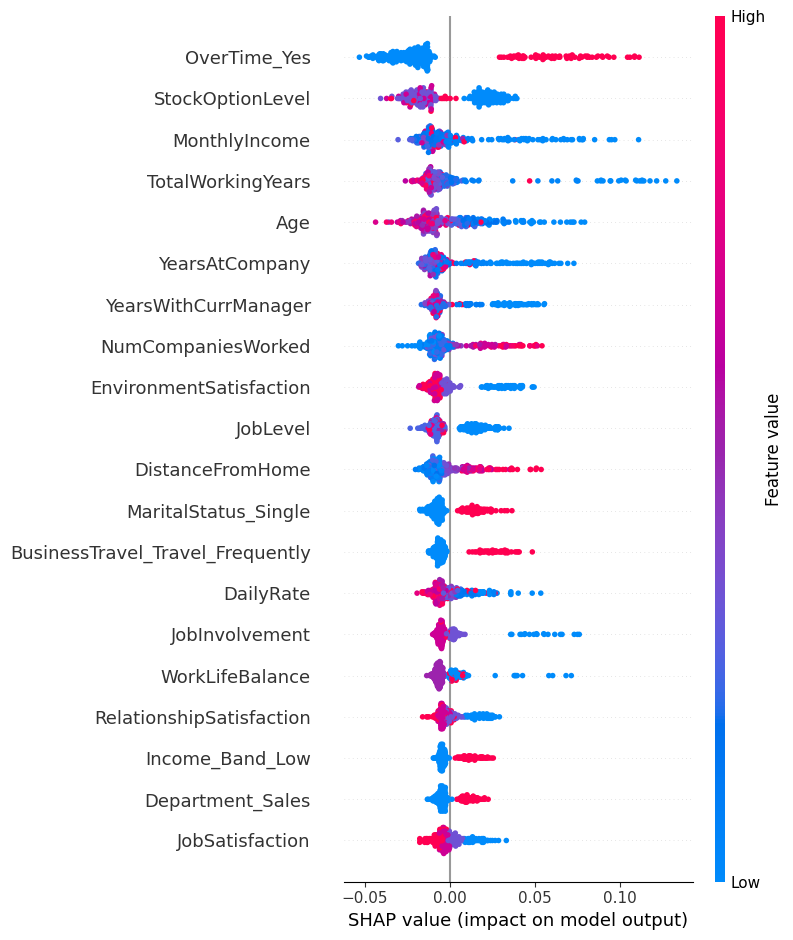

In [ ]:
shap.summary_plot(shap_values[:,:,1],X_test)


In [ ]:
print(explainer.expected_value)

[0.83698554 0.16301446]


In [ ]:
print(shap_values.shape)

(294, 54, 2)


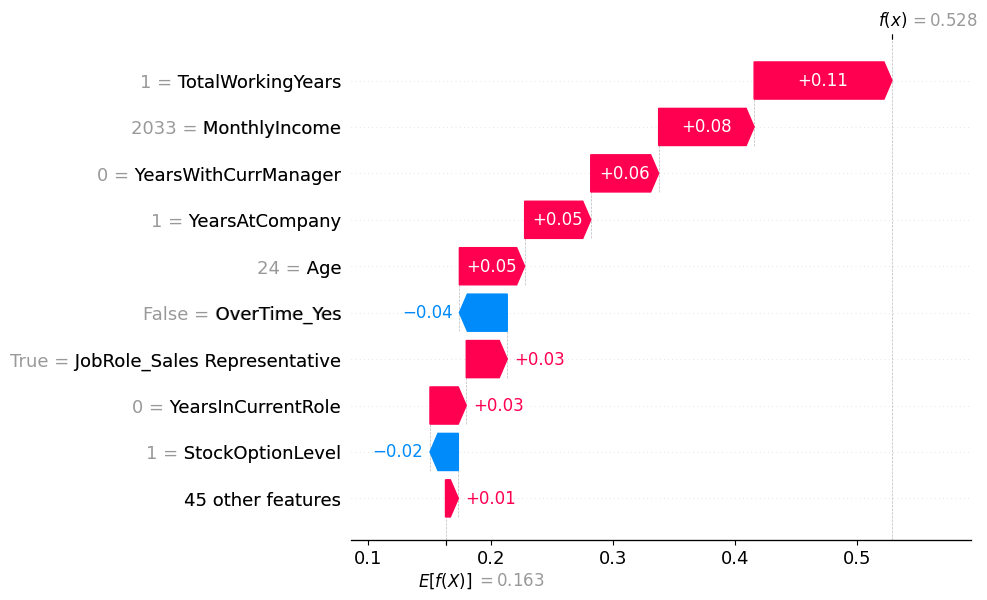

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=float(explainer.expected_value[1]),
        data= X_test.iloc[0].values,
        feature_names=X_test.columns.tolist()
    )
)

In [ ]:
feature_importance=pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : best_rf.feature_importances_
}).sort_values(by="Importance",ascending=False)

In [ ]:
top_features=feature_importance["Feature"].head(5).tolist()
print(top_features)

['MonthlyIncome', 'TotalWorkingYears', 'Age', 'DailyRate', 'HourlyRate']


In [ ]:
risk_drivers=pd.DataFrame(index=X_test.index)
for feature in top_features:
  risk_drivers[feature]=X_test[feature]

In [ ]:
risk_drivers["Predicted_Attrition"]=best_rf_pred
risk_drivers["Attrition_Probability"]=best_rf.predict_proba(X_test)[:,1]

In [ ]:
risk_drivers=risk_drivers.sort_values(by="Attrition_Probability",ascending=False)
risk_drivers.head(10)

,MonthlyIncome,TotalWorkingYears,Age,DailyRate,HourlyRate,Predicted_Attrition,Attrition_Probability
688,2121,1,19,419,37,1,0.868815
911,1118,1,25,599,73,1,0.792036
301,1200,0,18,812,69,1,0.734206
711,2404,3,29,906,92,1,0.623440
1402,1129,1,31,1276,59,1,0.590248
357,2174,3,21,756,99,1,0.577300
764,1052,1,28,1144,74,1,0.568548
17,2935,1,22,1123,96,1,0.552702
109,2871,1,22,534,59,1,0.537839
41,2341,1,27,1240,33,1,0.533645


In [ ]:
def generate_recommendation(row):
  recommendations = []
  if "OverTime_Yes" in row.index and row["OverTime_Yes"]==1:
    recommendations.append("Reduce overtime")
  if "JobSatisfaction" in row.index and row["JobSatisfaction"]<=2:
    recommendations.append("Improve job satisfaction")
  if "MonthlyIncome" in row.index and row["MonthlyIncome"]<X_train["MonthlyIncome"].median():
    recommendations.append("Review Compensation")
  if "YearSinceLastPromotion" in row.index and row["YearSinceLastPromotion"]>5:
    recommendations.append("Career Development Discussion")
  if not recommendations:
    recommendations.append("Continue Engagement")
  return ", ".join(recommendations)


In [ ]:
risk_drivers["Recommendation"]=X_test.apply(generate_recommendation,axis=1)

In [ ]:
risk_drivers.head(10)

,MonthlyIncome,TotalWorkingYears,Age,DailyRate,HourlyRate,Predicted_Attrition,Attrition_Probability,Recommendation
688,2121,1,19,419,37,1,0.868815,"Reduce overtime, Improve job satisfaction, Rev..."
911,1118,1,25,599,73,1,0.792036,"Reduce overtime, Review Compensation"
301,1200,0,18,812,69,1,0.734206,Review Compensation
711,2404,3,29,906,92,1,0.623440,"Reduce overtime, Improve job satisfaction, Rev..."
1402,1129,1,31,1276,59,1,0.590248,"Reduce overtime, Review Compensation"
357,2174,3,21,756,99,1,0.577300,"Reduce overtime, Improve job satisfaction, Rev..."
764,1052,1,28,1144,74,1,0.568548,"Improve job satisfaction, Review Compensation"
17,2935,1,22,1123,96,1,0.552702,"Reduce overtime, Review Compensation"
109,2871,1,22,534,59,1,0.537839,Review Compensation
41,2341,1,27,1240,33,1,0.533645,"Improve job satisfaction, Review Compensation"


In [ ]:
final_dataset = X_test.copy()
final_dataset["Predicted_Attrition"] = best_rf_pred
final_dataset["Attrition_Probability"] = best_rf.predict_proba(X_test)[:,1]
final_dataset["Recommendation"] = risk_drivers["Recommendation"]
final_dataset.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,Age_Group_56+,Income_Band_High,Income_Band_Low,Income_Band_Medium,Tenure_Bucket_10+ Years,Tenure_Bucket_3-5 Years,Tenure_Bucket_6-10 Years,Predicted_Attrition,Attrition_Probability,Recommendation
1061,24,830,13,2,4,78,3,1,2,2033,...,False,False,True,False,False,False,False,1,0.528278,"Improve job satisfaction, Review Compensation"
891,44,1117,2,1,1,72,4,1,4,2011,...,False,False,True,False,False,False,True,0,0.124089,Review Compensation
456,31,688,7,3,3,44,2,3,4,11557,...,False,False,False,False,False,True,False,0,0.155553,Continue Engagement
922,44,1199,4,2,3,92,4,5,1,19190,...,False,False,False,False,True,False,False,0,0.033512,Improve job satisfaction
69,36,318,9,3,4,79,2,1,3,3388,...,False,False,False,True,False,False,False,0,0.281248,"Reduce overtime, Review Compensation"


In [ ]:
final_dataset.to_csv("people_analytics_final.csv",index=False)

In [ ]:
print("Final dataset exported successfully!")

Final dataset exported successfully!


In [ ]:
import joblib

In [ ]:
print(type(best_rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
joblib.dump(best_rf,"attrition_model.pkl")

['attrition_model.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'attrition_model.pkl', 'people_analytics_final.csv', 'hr_cleaned.csv', 'sample_data']


In [ ]:
from google.colab import files
files.download("attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("people_analytics_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("")